# Insight 177: simple linear regression benchmark

This notebook replicates the benchmark model reported in the bottom panels of **Table 1** (out-of-sample $R^2$) and **Table 2** (directional accuracy) of OIES Energy Insight 177.

From Section 3 of the paper:

> the Tuesday-to-Tuesday change in Managed Money positions is regressed solely on the corresponding weekly rolling contract return over the same interval, estimated separately for each market.

For each COT reporting date $t$ and market $m$:

$$dMM_{m,t} = \beta_m \, r_{m,t} + \varepsilon_{m,t}, \qquad dMM_{m,t} = MM_{m,t} - MM_{m,t-5}, \qquad r_{m,t} = \ln\frac{P_{m,t}}{P_{m,t-5}}$$

$\beta_m$ is estimated on the preceding 104 weekly observations (two years, excluding the current observation) and applied to the contemporaneous return $r_{m,t}$ to predict $\widehat{dMM}_{m,t}$. Evaluation covers 2015-2025 with

$$R^2_{oos} = 1 - \frac{\sum (dMM_{m,t} - \widehat{dMM}_{m,t})^2}{\sum dMM_{m,t}^2}, \qquad Acc = \frac{1}{N}\sum \mathbb{1}\{\operatorname{sign}(dMM_{m,t}) = \operatorname{sign}(\widehat{dMM}_{m,t})\}$$

### Implementation choices

The paper leaves several details open. Each choice below was checked against the published tables; the comparison section at the end quantifies the remaining gap.

| Detail | Choice | Evidence |
|---|---|---|
| Intercept | **None** (regression through the origin) | Including an intercept moves directional accuracy ~3 pp away from the paper (e.g. CME WTI 2021: 46% vs published 71%). |
| Return | Log return of the rolling contract | Simple returns fit the published $R^2$ noticeably worse (WTI 2020). |
| Managed Money basis | Futures-only | The combined futures+options panel fits worse for Brent and WTI. |
| Rolling contract | Each contract is rolled out of at the settlement of the last trading day of the month preceding its expiry month (paper footnote 1), using the market's own trading days; returns are always computed on the contract actually held | Rolling one day later moves the mean $R^2$ gap from 0.01 pp to 0.12-0.36 pp, and treating returns across rolls naively to ~4 pp. |
| Week dating | The COT as-of date. When Tuesday is a holiday the CFTC reports as of Monday (e.g. 31 Dec 2018), and that week is assigned to the calendar year of the earliest as-of date across markets | Reproduces the paper's week counts (53 weeks in 2018, 52 in 2019). |
| Training window | 104 weekly observations strictly before $t$ | "data from the preceding two years, excluding the current observation". |

## Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from paper_replication.config import ReplicationConfig
from paper_replication.data import load_inputs, build_rolling_contract

DATA_DIR = PROJECT_ROOT / 'data_required'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'linear_regression'
(OUTPUT_DIR / 'figures').mkdir(parents=True, exist_ok=True)

# Paper column order and labels (Tables 1 and 2)
MARKETS = ['BRENT', 'WTI', 'GASOIL', 'HEATOIL', 'RBOB', 'NATGAS']
LABELS = {
    'BRENT': 'ICE Brent', 'WTI': 'CME WTI', 'GASOIL': 'ICE Gasoil',
    'HEATOIL': 'CME Heating Oil', 'RBOB': 'CME RBOB Gasoline', 'NATGAS': 'CME Natural Gas',
    'ALL': 'ALL Markets',
}

BASIS = 'futures_only'
TRAIN_WEEKS = 104
EVAL_START, EVAL_END = '2015-01-01', '2025-12-31'
FIT_INTERCEPT = False
print(PROJECT_ROOT)

/mnt/c/Users/Julien/Desktop/Capstone Project/paper_replication


## Load data

`load_inputs` from `src/paper_replication/data.py` reads the three input files, keeps the chosen Managed Money basis and the six markets, and checks for one row per market per week.

In [2]:
prices, meta, mm = load_inputs(ReplicationConfig(data_dir=DATA_DIR, basis=BASIS))

# One panel date per reporting week: the earliest as-of date across markets (CFTC uses Monday when Tuesday is a holiday)
mm['panel_date'] = mm.groupby('report_week_tuesday')['report_date'].transform('min')
mm.groupby('market')['report_date'].agg(['min', 'max', 'count'])

,min,max,count
market,,,
BRENT,2011-01-04,2026-08-25,817
GASOIL,2011-01-04,2026-08-25,817
HEATOIL,2009-01-06,2026-08-25,921
NATGAS,2009-01-06,2026-08-25,921
RBOB,2009-01-06,2026-08-25,921
WTI,2009-01-06,2026-08-25,921


## Rolling contract returns

`build_rolling_contract` from `src/paper_replication/data.py` rolls out of each contract at the settlement of the last trading day of the month preceding its expiry month, so the contract held at a close always expires in the calendar month after the next trading day. Each generic nearby is mapped to a specific contract using the expiry schedule, and the daily log return on day $t$ is computed on the contract held at the close of $t-1$, using that contract's prices on both days. Differencing the generic series across a roll or expiry would add spurious jumps.

The rows below show a WTI roll (31 March 2020, CLK20 to CLM20) and expiry (CLK20 last traded on 21 April, so on 22 April CLM20 becomes nearby 1), and a Heating Oil expiry day (HOF20 expires on 31 December 2019, which is also HOG20's roll date, so the position holds nearby 3 at that close). `contract_key` is the contract held at the close and `nearby_offset` its distance from nearby 1.

In [3]:
daily = build_rolling_contract(prices, meta)
examples = {'WTI': ['2020-03-30', '2020-03-31', '2020-04-01', '2020-04-21', '2020-04-22'], 'HEATOIL': ['2019-12-30', '2019-12-31', '2020-01-02']}
pd.concat([
    daily.loc[daily['market'].eq(market) & daily['date'].isin(pd.to_datetime(dates))]
    for market, dates in examples.items()
])[['market', 'date', 'roll_date', 'nearby_offset', 'contract_key', 'price', 'daily_log_return']]

,market,date,roll_date,nearby_offset,contract_key,price,daily_log_return
25299,WTI,2020-03-30,2020-03-31,0,136,20.09,-0.068296
25300,WTI,2020-03-31,2020-04-30,1,137,24.51,0.019227
25301,WTI,2020-04-01,2020-04-30,1,137,23.74,-0.031920
25314,WTI,2020-04-21,2020-04-30,1,137,11.57,-0.568589
25315,WTI,2020-04-22,2020-04-30,0,137,13.78,0.174803
11890,HEATOIL,2019-12-30,2019-12-31,1,133,204.38,-0.003955
11891,HEATOIL,2019-12-31,2020-01-31,2,134,201.65,-0.010328
11892,HEATOIL,2020-01-02,2020-01-31,1,134,201.98,0.001635


In [4]:
daily.groupby('market')['daily_log_return'].agg(
    days='count', mean_abs=lambda s: s.abs().mean(), max_abs=lambda s: s.abs().max()
).loc[MARKETS]

,days,mean_abs,max_abs
market,,,
BRENT,4560,0.015235,0.259951
WTI,4449,0.017134,0.568589
GASOIL,4561,0.015281,0.192111
HEATOIL,4449,0.014978,0.215315
RBOB,4449,0.015590,0.263777
NATGAS,4449,0.022870,0.238344


## Weekly panel

Prices are sampled at each market's COT as-of date (last settlement on or before it), so the weekly return covers the same interval as the change in positions.

In [5]:
weekly = []
for market in MARKETS:
    positions = mm.loc[mm['market'].eq(market), ['market', 'report_week_tuesday', 'report_date', 'panel_date', 'mm_net']].sort_values('report_date')
    returns = daily.loc[daily['market'].eq(market), ['date', 'cum_log_return']].sort_values('date')
    w = pd.merge_asof(positions, returns, left_on='report_date', right_on='date', direction='backward')
    w['dmm'] = w['mm_net'].diff()
    w['weekly_return'] = w['cum_log_return'].diff()
    weekly.append(w.dropna(subset=['dmm', 'weekly_return']))
weekly = pd.concat(weekly, ignore_index=True)[['market', 'report_week_tuesday', 'report_date', 'panel_date', 'mm_net', 'dmm', 'weekly_return']]
weekly.head()

,market,report_week_tuesday,report_date,panel_date,mm_net,dmm,weekly_return
0,BRENT,2011-01-11,2011-01-11,2011-01-11,128399.0,6866.0,0.039019
1,BRENT,2011-01-18,2011-01-18,2011-01-18,120893.0,-7506.0,0.006051
2,BRENT,2011-01-25,2011-01-25,2011-01-25,82944.0,-37949.0,-0.026420
3,BRENT,2011-02-01,2011-02-01,2011-02-01,92505.0,9561.0,0.066497
4,BRENT,2011-02-08,2011-02-08,2011-02-08,79584.0,-12921.0,-0.013733


## Rolling out-of-sample regressions

For each market and each evaluation week, fit OLS on the previous `TRAIN_WEEKS` observations and predict the current week from its contemporaneous return.

In [6]:
def design(returns):
    returns = np.asarray(returns, dtype=float)
    return np.column_stack([np.ones_like(returns), returns]) if FIT_INTERCEPT else returns[:, None]


rows = []
for market, w in weekly.groupby('market', sort=False):
    w = w.sort_values('report_date').reset_index(drop=True)
    for i in range(TRAIN_WEEKS, len(w)):
        panel_date = w.at[i, 'panel_date']
        if not (pd.Timestamp(EVAL_START) <= panel_date <= pd.Timestamp(EVAL_END)):
            continue
        train = w.iloc[i - TRAIN_WEEKS:i]
        coef = np.linalg.lstsq(design(train['weekly_return']), train['dmm'].to_numpy(), rcond=None)[0]
        rows.append({
            'market': market,
            'report_week_tuesday': w.at[i, 'report_week_tuesday'],
            'report_date': w.at[i, 'report_date'],
            'panel_date': panel_date,
            'year': panel_date.year,
            'weekly_return': w.at[i, 'weekly_return'],
            'beta': coef[-1],
            'intercept': coef[0] if FIT_INTERCEPT else 0.0,
            'actual_change': w.at[i, 'dmm'],
            'predicted_change': float(design([w.at[i, 'weekly_return']])[0] @ coef),
        })
predictions = pd.DataFrame(rows)
predictions.groupby(['year', 'market']).size().unstack()[MARKETS]

market,BRENT,WTI,GASOIL,HEATOIL,RBOB,NATGAS
year,,,,,,
2015,52,52,52,52,52,52
2016,52,52,52,52,52,52
2017,52,52,52,52,52,52
2018,53,53,53,53,53,53
2019,52,52,52,52,52,52
2020,52,52,52,52,52,52
2021,52,52,52,52,52,52
2022,52,52,52,52,52,52
2023,52,52,52,52,52,52


## Out-of-sample metrics

In [7]:
def r2_oos(d):
    return 1 - np.sum((d['actual_change'] - d['predicted_change']) ** 2) / np.sum(d['actual_change'] ** 2)


def directional_accuracy(d):
    return np.mean(np.sign(d['actual_change']) == np.sign(d['predicted_change']))


def metric_table(predictions, metric):
    subsets = {year: predictions.loc[predictions['year'].eq(year)] for year in sorted(predictions['year'].unique())}
    subsets['Cumulative'] = predictions
    table = {}
    for label, d in subsets.items():
        values = {market: metric(d.loc[d['market'].eq(market)]) for market in MARKETS}
        values['ALL'] = metric(d)  # pooled across markets
        table[label] = values
    return pd.DataFrame(table).T.rename(columns=LABELS)


def pct(table):
    return table.style.format('{:.2f}%')


r2_table = metric_table(predictions, r2_oos) * 100
accuracy_table = metric_table(predictions, directional_accuracy) * 100
print('Out-of-sample R^2, simple linear regression')
pct(r2_table)

Out-of-sample R^2, simple linear regression


,ICE Brent,CME WTI,ICE Gasoil,CME Heating Oil,CME RBOB Gasoline,CME Natural Gas,ALL Markets
2015,-6.51%,19.58%,21.62%,-15.65%,15.36%,21.27%,13.68%
2016,15.42%,28.89%,26.42%,19.06%,26.34%,26.17%,23.36%
2017,33.48%,32.65%,26.44%,22.76%,32.10%,34.89%,32.57%
2018,15.33%,19.12%,40.59%,37.98%,24.71%,18.43%,19.89%
2019,30.54%,32.10%,46.95%,12.60%,40.09%,33.04%,33.03%
2020,1.48%,-161.53%,-79.68%,-68.53%,-55.58%,11.84%,-45.90%
2021,36.43%,5.21%,26.98%,7.29%,18.46%,24.92%,24.18%
2022,-9.67%,43.63%,-35.92%,-5.23%,7.23%,-16.53%,0.23%
2023,21.65%,37.86%,17.82%,7.22%,22.53%,23.30%,26.75%
2024,45.78%,45.26%,39.05%,25.04%,20.92%,33.06%,41.85%


In [8]:
print('Out-of-sample directional accuracy, simple linear regression')
pct(accuracy_table)

Out-of-sample directional accuracy, simple linear regression


,ICE Brent,CME WTI,ICE Gasoil,CME Heating Oil,CME RBOB Gasoline,CME Natural Gas,ALL Markets
2015,63.46%,63.46%,69.23%,59.62%,67.31%,76.92%,66.67%
2016,71.15%,76.92%,73.08%,61.54%,65.38%,76.92%,70.83%
2017,69.23%,69.23%,67.31%,63.46%,71.15%,76.92%,69.55%
2018,54.72%,69.81%,73.58%,71.70%,66.04%,67.92%,67.30%
2019,67.31%,76.92%,75.00%,63.46%,69.23%,73.08%,70.83%
2020,65.38%,63.46%,73.08%,67.31%,69.23%,65.38%,67.31%
2021,71.15%,71.15%,69.23%,63.46%,67.31%,75.00%,69.55%
2022,73.08%,69.23%,67.31%,67.31%,59.62%,59.62%,66.03%
2023,73.08%,88.46%,65.38%,59.62%,63.46%,69.23%,69.87%
2024,75.47%,75.47%,81.13%,71.70%,66.04%,79.25%,74.84%


## Comparison with the published tables

Values transcribed from the *Simple Linear Regression* panels of Tables 1 and 2.

In [9]:
PAPER_COLUMNS = [LABELS[m] for m in MARKETS] + [LABELS['ALL']]
PAPER_R2 = pd.DataFrame({
    2015: [-6.51, 19.58, 21.62, -15.65, 15.36, 21.27, 13.68],
    2016: [15.15, 28.89, 26.42, 19.06, 26.34, 26.17, 23.27],
    2017: [33.30, 32.65, 26.44, 22.76, 32.10, 34.89, 32.53],
    2018: [15.34, 19.12, 40.59, 37.98, 24.71, 18.43, 19.89],
    2019: [30.54, 32.10, 46.95, 12.60, 40.09, 33.04, 33.03],
    2020: [1.48, -161.53, -79.68, -68.53, -55.58, 11.84, -45.90],
    2021: [36.43, 5.21, 26.98, 7.29, 18.46, 24.92, 24.18],
    2022: [-9.67, 43.63, -35.92, -5.23, 7.23, -16.53, 0.23],
    2023: [21.65, 37.86, 17.82, 7.22, 22.53, 23.30, 26.75],
    2024: [45.78, 45.26, 39.05, 25.04, 20.92, 33.06, 41.85],
    2025: [49.83, -2.76, 32.01, 9.36, 28.46, 26.86, 34.70],
    'Cumulative': [27.10, 11.52, 22.59, 10.77, 17.98, 24.17, 21.08],
}, index=PAPER_COLUMNS).T
PAPER_ACCURACY = pd.DataFrame({
    2015: [61.54, 63.46, 69.23, 59.62, 67.31, 76.92, 66.35],
    2016: [69.23, 76.92, 73.08, 61.54, 65.38, 76.92, 70.51],
    2017: [69.23, 69.23, 67.31, 63.46, 71.15, 76.92, 69.55],
    2018: [54.72, 69.81, 73.58, 71.70, 66.04, 67.92, 67.30],
    2019: [67.31, 76.92, 75.00, 63.46, 69.23, 73.08, 70.83],
    2020: [65.38, 63.46, 73.08, 67.31, 69.23, 65.38, 67.31],
    2021: [71.15, 71.15, 69.23, 63.46, 67.31, 75.00, 69.55],
    2022: [73.08, 69.23, 67.31, 67.31, 59.62, 59.62, 66.03],
    2023: [73.08, 88.46, 65.38, 59.62, 63.46, 69.23, 69.87],
    2024: [75.47, 75.47, 79.25, 71.70, 66.04, 79.25, 74.53],
    2025: [82.69, 71.15, 71.15, 59.62, 75.00, 61.54, 70.19],
    'Cumulative': [69.34, 72.30, 71.25, 64.46, 67.25, 71.08, 69.28],
}, index=PAPER_COLUMNS).T

r2_diff = r2_table - PAPER_R2
accuracy_diff = accuracy_table - PAPER_ACCURACY
summary = pd.DataFrame({
    'R2: mean |diff| (pp)': r2_diff.abs().mean(),
    'R2: cumulative replicated': r2_table.loc['Cumulative'],
    'R2: cumulative paper': PAPER_R2.loc['Cumulative'],
    'Acc: mean |diff| (pp)': accuracy_diff.abs().mean(),
    'Acc: cumulative replicated': accuracy_table.loc['Cumulative'],
    'Acc: cumulative paper': PAPER_ACCURACY.loc['Cumulative'],
})
summary.style.format('{:.2f}')

,R2: mean |diff| (pp),R2: cumulative replicated,R2: cumulative paper,Acc: mean |diff| (pp),Acc: cumulative replicated,Acc: cumulative paper
ICE Brent,0.04,27.14,27.10,0.35,69.69,69.34
CME WTI,0.00,11.52,11.52,0.00,72.30,72.30
ICE Gasoil,0.00,22.59,22.59,0.17,71.43,71.25
CME Heating Oil,0.00,10.77,10.77,0.00,64.46,64.46
CME RBOB Gasoline,0.00,17.98,17.98,0.00,67.25,67.25
CME Natural Gas,0.00,24.17,24.17,0.00,71.08,71.08
ALL Markets,0.01,21.10,21.08,0.09,69.37,69.28


In [10]:
print('R^2: replicated minus paper (percentage points)')
r2_diff.style.format('{:+.2f}').background_gradient(cmap='RdBu', vmin=-5, vmax=5)

R^2: replicated minus paper (percentage points)


,ICE Brent,CME WTI,ICE Gasoil,CME Heating Oil,CME RBOB Gasoline,CME Natural Gas,ALL Markets
2015,-0.00,-0.00,-0.00,-0.00,+0.00,+0.00,+0.00
2016,+0.27,-0.00,+0.00,-0.00,-0.00,+0.00,+0.09
2017,+0.18,-0.00,+0.00,-0.00,+0.00,+0.00,+0.04
2018,-0.01,+0.00,-0.00,-0.00,+0.00,+0.00,+0.00
2019,+0.00,-0.00,+0.00,+0.00,-0.00,+0.00,-0.00
2020,-0.00,+0.00,+0.00,-0.00,-0.00,-0.00,-0.00
2021,-0.00,-0.00,+0.00,-0.00,-0.00,+0.00,-0.00
2022,-0.00,+0.00,+0.00,-0.00,-0.00,-0.00,-0.00
2023,+0.00,-0.00,+0.00,-0.00,-0.00,+0.00,-0.00
2024,-0.00,+0.00,-0.00,+0.00,+0.00,-0.00,-0.00


In [11]:
print('Directional accuracy: replicated minus paper (percentage points)')
accuracy_diff.style.format('{:+.2f}').background_gradient(cmap='RdBu', vmin=-5, vmax=5)

Directional accuracy: replicated minus paper (percentage points)


,ICE Brent,CME WTI,ICE Gasoil,CME Heating Oil,CME RBOB Gasoline,CME Natural Gas,ALL Markets
2015,+1.92,+0.00,+0.00,-0.00,-0.00,+0.00,+0.32
2016,+1.92,+0.00,-0.00,-0.00,+0.00,+0.00,+0.32
2017,+0.00,+0.00,-0.00,+0.00,+0.00,+0.00,+0.00
2018,-0.00,+0.00,+0.00,-0.00,-0.00,+0.00,-0.00
2019,-0.00,+0.00,+0.00,+0.00,+0.00,-0.00,+0.00
2020,+0.00,+0.00,-0.00,-0.00,+0.00,+0.00,-0.00
2021,+0.00,+0.00,+0.00,+0.00,-0.00,+0.00,+0.00
2022,-0.00,+0.00,-0.00,-0.00,-0.00,-0.00,-0.00
2023,-0.00,+0.00,+0.00,-0.00,+0.00,+0.00,+0.00
2024,+0.00,+0.00,+1.88,-0.00,-0.00,-0.00,+0.31


### Sensitivity: including an intercept

Shows why the no-intercept specification was adopted. With an intercept, a persistent drift in positions over the training window can flip the sign of predictions for weeks with small returns.

In [12]:
def run_variant(fit_intercept):
    out = []
    for market, w in weekly.groupby('market', sort=False):
        w = w.sort_values('report_date').reset_index(drop=True)
        X = np.column_stack([np.ones(len(w)), w['weekly_return']]) if fit_intercept else w[['weekly_return']].to_numpy()
        y = w['dmm'].to_numpy()
        for i in range(TRAIN_WEEKS, len(w)):
            if pd.Timestamp(EVAL_START) <= w.at[i, 'panel_date'] <= pd.Timestamp(EVAL_END):
                coef = np.linalg.lstsq(X[i - TRAIN_WEEKS:i], y[i - TRAIN_WEEKS:i], rcond=None)[0]
                out.append({'market': market, 'year': w.at[i, 'panel_date'].year,
                            'actual_change': y[i], 'predicted_change': X[i] @ coef})
    return pd.DataFrame(out)


variant = run_variant(fit_intercept=True)
pd.DataFrame({
    'R2 mean |diff| vs paper, no intercept': r2_diff.abs().mean(),
    'R2 mean |diff| vs paper, with intercept': (metric_table(variant, r2_oos) * 100 - PAPER_R2).abs().mean(),
    'Acc mean |diff| vs paper, no intercept': accuracy_diff.abs().mean(),
    'Acc mean |diff| vs paper, with intercept': (metric_table(variant, directional_accuracy) * 100 - PAPER_ACCURACY).abs().mean(),
}).style.format('{:.2f}')

,"R2 mean |diff| vs paper, no intercept","R2 mean |diff| vs paper, with intercept","Acc mean |diff| vs paper, no intercept","Acc mean |diff| vs paper, with intercept"
ICE Brent,0.04,0.84,0.35,3.03
CME WTI,0.00,0.97,0.00,4.63
ICE Gasoil,0.00,1.15,0.17,1.51
CME Heating Oil,0.00,1.02,0.00,3.14
CME RBOB Gasoline,0.00,0.51,0.00,1.92
CME Natural Gas,0.00,2.22,0.00,1.86
ALL Markets,0.01,1.07,0.09,1.47


## Diagnostics

Predicted vs actual weekly changes (thousand lots), in the layout of the paper's Figure 4, and the rolling slope estimates.

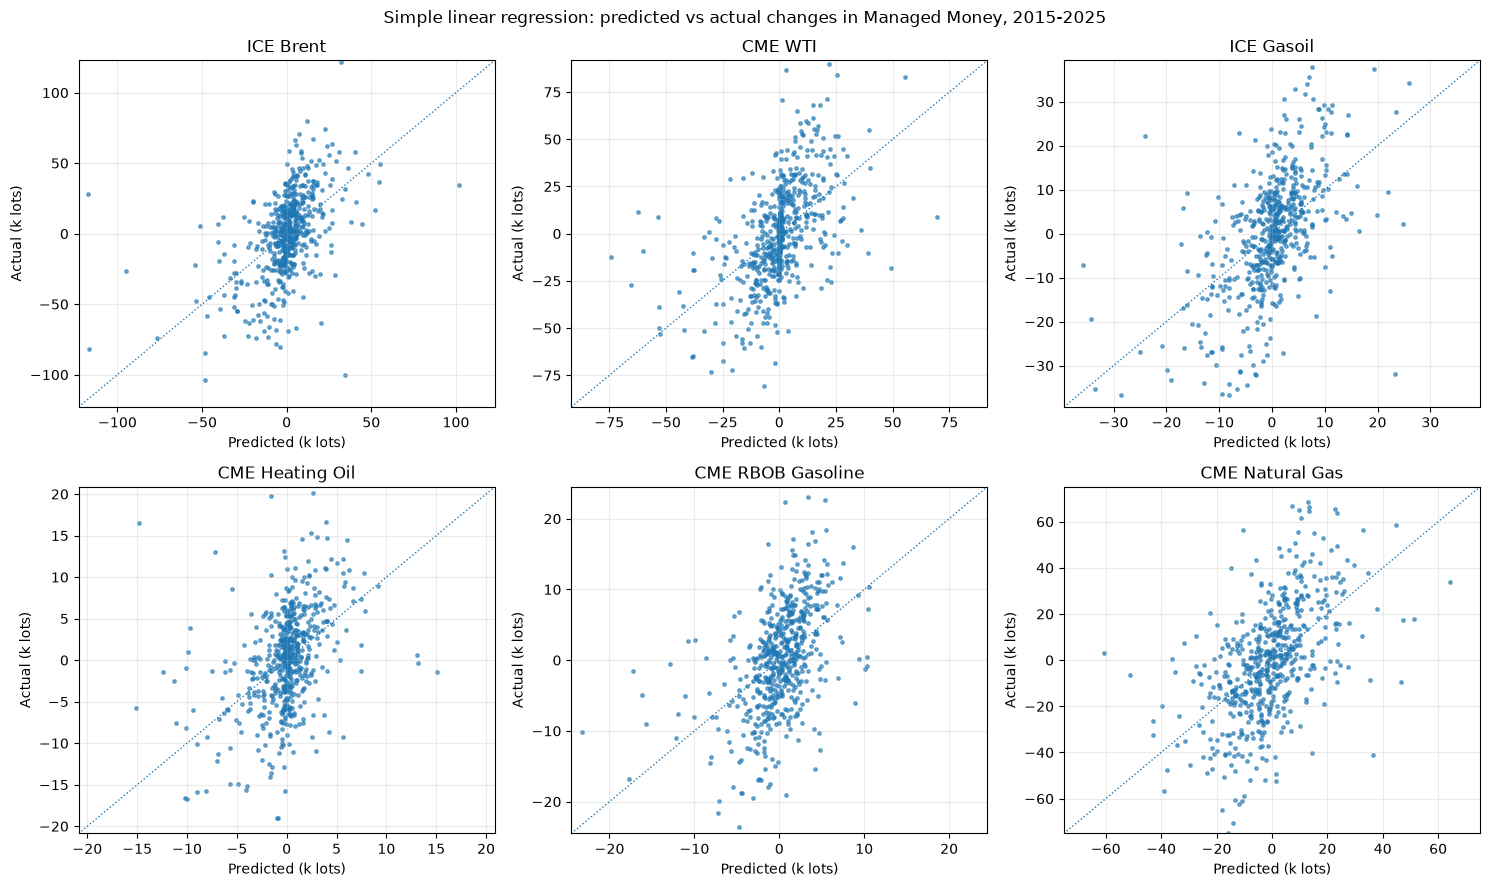

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for axis, market in zip(axes.flat, MARKETS):
    d = predictions.loc[predictions['market'].eq(market)]
    x, y = d['predicted_change'] / 1e3, d['actual_change'] / 1e3
    lim = np.nanpercentile(np.abs(np.r_[x, y]), 99.5) * 1.05
    axis.scatter(x, y, s=6, alpha=0.6)
    axis.plot([-lim, lim], [-lim, lim], linestyle=':', linewidth=1)
    axis.set(xlim=(-lim, lim), ylim=(-lim, lim), title=LABELS[market], xlabel='Predicted (k lots)', ylabel='Actual (k lots)')
    axis.grid(alpha=0.25)
fig.suptitle('Simple linear regression: predicted vs actual changes in Managed Money, 2015-2025')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'figures' / 'predicted_vs_actual_changes.png', dpi=160)
plt.show()

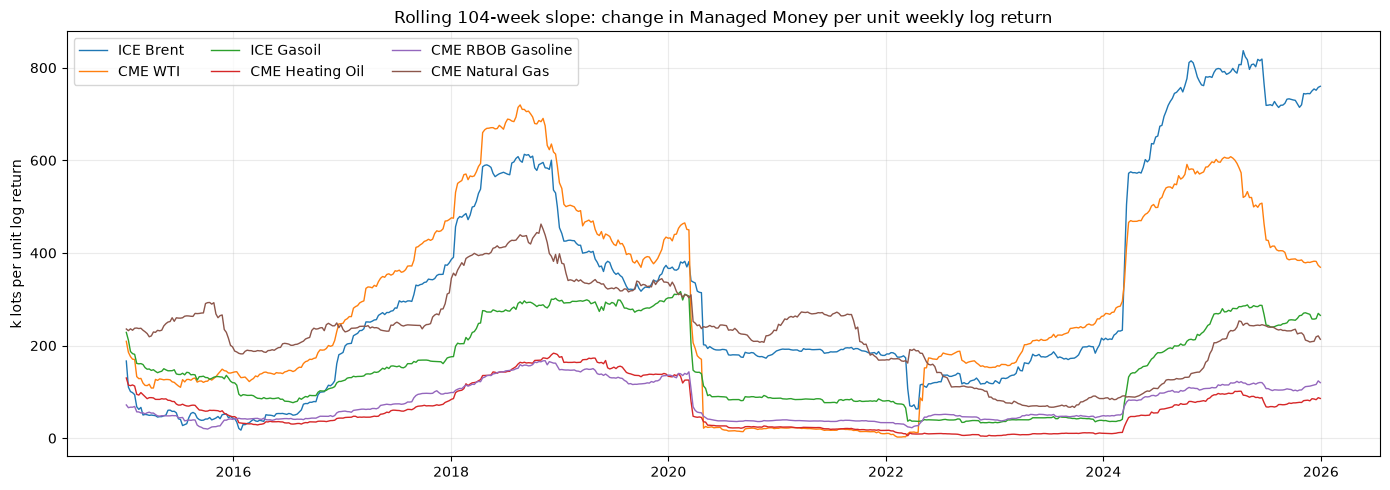

In [14]:
fig, axis = plt.subplots(figsize=(14, 5))
for market in MARKETS:
    d = predictions.loc[predictions['market'].eq(market)]
    axis.plot(d['panel_date'], d['beta'] / 1e3, label=LABELS[market], linewidth=1)
axis.set(title='Rolling 104-week slope: change in Managed Money per unit weekly log return', ylabel='k lots per unit log return')
axis.grid(alpha=0.25)
axis.legend(ncol=3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'figures' / 'rolling_beta.png', dpi=160)
plt.show()

## Save outputs

In [15]:
predictions.to_csv(OUTPUT_DIR / 'predictions.csv', index=False)
weekly.to_csv(OUTPUT_DIR / 'weekly_panel.csv', index=False)
r2_table.to_csv(OUTPUT_DIR / 'r2_oos.csv')
accuracy_table.to_csv(OUTPUT_DIR / 'directional_accuracy.csv')
pd.concat({'replicated': r2_table, 'paper': PAPER_R2, 'difference': r2_diff}, axis=1).to_csv(OUTPUT_DIR / 'r2_oos_vs_paper.csv')
pd.concat({'replicated': accuracy_table, 'paper': PAPER_ACCURACY, 'difference': accuracy_diff}, axis=1).to_csv(OUTPUT_DIR / 'directional_accuracy_vs_paper.csv')
sorted(p.relative_to(PROJECT_ROOT).as_posix() for p in OUTPUT_DIR.rglob('*') if p.is_file())

['outputs/linear_regression/directional_accuracy.csv',
 'outputs/linear_regression/directional_accuracy_vs_paper.csv',
 'outputs/linear_regression/figures/predicted_vs_actual_changes.png',
 'outputs/linear_regression/figures/rolling_beta.png',
 'outputs/linear_regression/predictions.csv',
 'outputs/linear_regression/r2_oos.csv',
 'outputs/linear_regression/r2_oos_vs_paper.csv',
 'outputs/linear_regression/weekly_panel.csv']